C:\Users\owner\Documents\Projects\dysregulated-persistence\src\analysis_functions.py:32: RuntimeWarning: invalid value encountered in divide
  m = (m - m.mean(axis=0)) / m.std(axis=0)


max ev: 6.094979017903852, number above threshold: 0
7.446124609942542


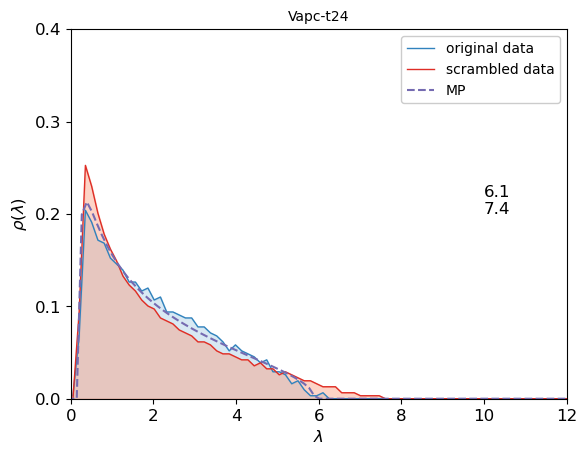

In [189]:
import src.analysis_functions as af
import src.data_functions as df
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import importlib



importlib.reload(af)
importlib.reload(df)

fsize=12

def get_data_for_plot(path, norm=True, log=False, norm_method='sum', norm_sum=1):
    # get annotated matrix from file
    amat = df.read_from_csv(path)
    # calculate the eigenvalues and plot:
    # remove tracker genes from the matrix
    t_genes = ['16s_mature', '16s_unprocessed']
    # amat.reset_filters()
    index = [np.where(amat.var_names == val)[0][0] for val in t_genes if val in amat.var_names]
    # filter the genes
    amat.filtered_var[np.array(index).astype(int)] = False
    m = amat.get_filtered_matrix().m
    pcs, pcs1, m = af.get_eig_dist(m, norm=norm, log=log, norm_method=norm_method, norm_sum=norm_sum)
    return pcs, pcs1, m.shape[0], m

def plot_eigvals(ax, pcs, pcs1, N, x_max, y_max, n_bins, x_label=True, y_label=True):
    # plot the eigenvalue distribution of the normalized filtered matrix
    # define limits and bin number
    P = len(pcs)
    scale = 1  # scale factor for the Marchenko-Pastur distribution
    edges = np.linspace(-0.1, x_max, num=n_bins)

    # remove zeros in pcs and pcs1
    # if alpha>1 adjust the scale factor to match theoretical results
    if P / N > 1:
        scale = N / P
        pcs = pcs[pcs != 0]
        pcs1 = pcs1[pcs1 != 0]

    # first plot
    counts, bins = np.histogram(pcs, bins=edges, density=True)
    ax.plot(bins[1:], scale * counts, color='#3182bd', linewidth=1, label='original data')
    ax.fill_between(bins[1:], scale * counts, 0, color='#9ecae1', alpha=.4)
    # second plot
    counts, bins = np.histogram(pcs1, bins=edges, density=True)
    ax.plot(bins[1:], scale * counts, color='#de2d26', linewidth=1, label='scrambled data')
    ax.fill_between(bins[1:], scale * counts, 0, color='#fc9272', alpha=.4)
    # plot analytical Marchenko-Pastur distribution
    x = np.linspace(-0.1, x_max, 100)
    y = [af.mp_distribution(val, P / N) for val in x]
    ax.plot(x, y, color='#756bb1', linestyle='dashed', label='MP')
    # labels and limits
    if x_label:
        ax.set_xlabel("$\lambda$", fontsize=fsize)
    if y_label:
        ax.set_ylabel(r"$\rho(\lambda)$", fontsize=fsize)
    ax.set_ylim(0, y_max)
    ax.set_xlim(0, x_max)
    # set x_ticks with difference of 2
    ax.set_xticks(np.arange(0, (x_max // 2) * 2 + 2, 2))
    # set y_ticks with difference of 0.1
    ax.set_yticks(np.arange(0, (y_max // 0.1) * 0.1 + 0.1, 0.1))
    ax.legend(facecolor='white', framealpha=1, fontsize=fsize-2, loc='upper right')
    # set the font size of the ticks
    ax.tick_params(axis='both', which='major', labelsize=fsize)

nbins = 81
x_max = 12
y_max = 0.4
fig, ax = plt.subplots()
# plot individual distributions
norm = True
log = False
norm_method = 'sum'
norm_sum = 1
# set style to default
plt.style.use('default')
plt.rcParams.update({'font.size': fsize})
# create grid of experimental results
# subplot 1
# get annotated matrix from file
root_dir = r"C:\Users\owner\Documents\Projects\dysregulated-persistence"
file_name = 'sample_15a_filtered.csv'
path = os.path.join(root_dir,'data_for_paper', file_name)
pcs, pcs1, N, m = get_data_for_plot(path, norm=norm, log=log, norm_method=norm_method, norm_sum=norm_sum)
ax.set_title('Vapc-t24', fontsize=fsize-2)
ax.text(10,0.2,f'{np.max(pcs):.1f}\n{np.max(pcs1):.1f}')
plot_eigvals(ax,pcs, pcs1, N, x_max, y_max, nbins)
print(f'max ev: {np.max(pcs)}, number above threshold: {sum(pcs>np.max(pcs1))}')
print(np.max(pcs1))

In [119]:

len(pcs)

2071

0.9763941687178656


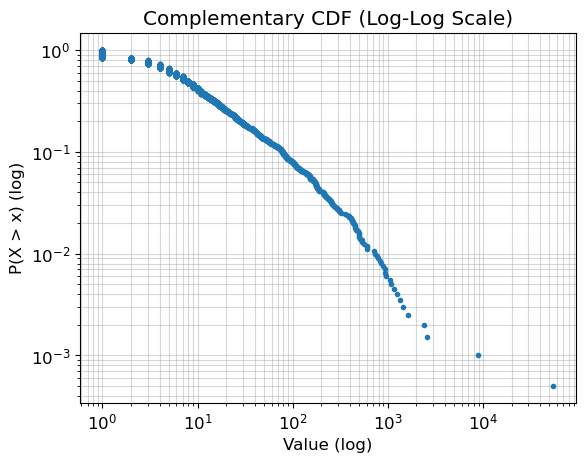

In [60]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
root_dir = r"C:\Users\owner\Documents\Projects\dysregulated-persistence"
file_name = ('Expira_biorep_t0A_filtered.csv')
df = pd.read_csv(os.path.join(root_dir,'data_for_paper', file_name), index_col=0, header=0)
m = df.to_numpy()
gene_sums = m.sum(axis=0)
def plot_ccdf(data, label=None):
    # 1. Sort the data in ascending order
    sorted_data = np.sort(data)

    # 2. Calculate the CDF values (from 1/N to 1)
    # n is the number of data points
    n = len(sorted_data)
    cdf = np.arange(1, n + 1) / n

    # 3. Calculate the CCDF (1 - CDF)
    # We use (n - i) / n to avoid the last point being 0,
    # which can't be plotted on a log scale.
    ccdf = 1 - cdf + (1/n)

    # 4. Plotting
    plt.loglog(sorted_data, ccdf, marker='.', linestyle='none', label=label)
    plt.xlabel('Value (log)')
    plt.ylabel('P(X > x) (log)')
    plt.title('Complementary CDF (Log-Log Scale)')
    plt.grid(True, which="both", ls="-", alpha=0.5)
plot_ccdf(gene_sums)
print(sum(sum(m==0))/len(m.flatten()))

In [214]:
import os
import importlib
importlib.reload(af)
importlib.reload(df)

#parameters:
norm = True
log = False
norm_method = 'sum'
norm_sum = 1
path = r'C:\Users\owner\Documents\Projects\dysregulated-persistence\data_for_paper'
file_data = []
for file in os.listdir(path):
    file_name = os.path.join(path, file)
    pcs, pcs1, N, m = get_data_for_plot(file_name, norm=norm, log=log, norm_method=norm_method, norm_sum=norm_sum)
    max_ev = np.max(pcs)
    max_ev_scrambled = np.max(pcs1)
    entropy = af.get_entropy(pcs)
    entropy_scrambled = af.get_entropy(pcs1)
    l_plus = (1+np.sqrt(m.shape[1]/m.shape[0]))**2
    file_data.append({
                'file_name': file,
                'max_ev': max_ev,
                'max_ev_scrambled': max_ev_scrambled,
                'eig_diff': max_ev - max_ev_scrambled,
                'sum_denoised_ev': np.sum(pcs[pcs>max_ev_scrambled]),
                'fraction_non-zero': np.sum(m.flatten()>0)/len(m.flatten()),
            })
data = pd.DataFrame(file_data)
category = ['r','r','d','r','d','r','r','d','d','d','d','r','r','r','d']
data['category'] = category

data

C:\Users\owner\Documents\Projects\dysregulated-persistence\src\analysis_functions.py:32: RuntimeWarning: invalid value encountered in divide
  m = (m - m.mean(axis=0)) / m.std(axis=0)
C:\Users\owner\Documents\Projects\dysregulated-persistence\src\analysis_functions.py:32: RuntimeWarning: invalid value encountered in divide
  m = (m - m.mean(axis=0)) / m.std(axis=0)


,file_name,max_ev,max_ev_scrambled,eig_diff,sum_denoised_ev,fraction_non-zero,category
0,adam_matrix_filtered.csv,11.249618,6.617565,4.632052,77.555818,0.041340,r
1,Expira_biorep_t0A_filtered.csv,17.158693,8.752450,8.406243,55.513123,0.021652,r
2,sample_13a_filtered.csv,8.242494,7.845024,0.397470,8.242494,0.029028,d
3,sample_13b_filtered.csv,14.258587,7.556177,6.702410,51.360053,0.028372,r
4,sample_15a_filtered.csv,6.094979,7.468920,-1.373941,0.000000,0.018365,d
5,sample_15b_filtered.csv,17.281707,7.347286,9.934421,68.407378,0.041333,r
6,sample_2b_filtered.csv,19.408976,6.876644,12.532331,81.984762,0.047683,r
7,SHX_biorep2A.csv,9.502631,7.420511,2.082119,32.758251,0.026177,d
8,SHX_biorep2B.csv,7.650878,7.442849,0.208029,7.650878,0.024200,d
9,SHX_biorep4A.csv,8.332470,6.763577,1.568893,8.332470,0.029320,d


In [215]:
from scipy import stats
dis = data['sum_denoised_ev'].loc[data['category'] == 'd']
reg = data['sum_denoised_ev'].loc[data['category'] == 'r']
u_stat, p_value = stats.mannwhitneyu(dis, reg, alternative='less')

print(f"U-statistic: {u_stat}")
print(f"P-value: {p_value}")

U-statistic: 0.0
P-value: 0.0001554001554001554


P-value: 0.7046148142245103, R-value: 0.10687337786121337


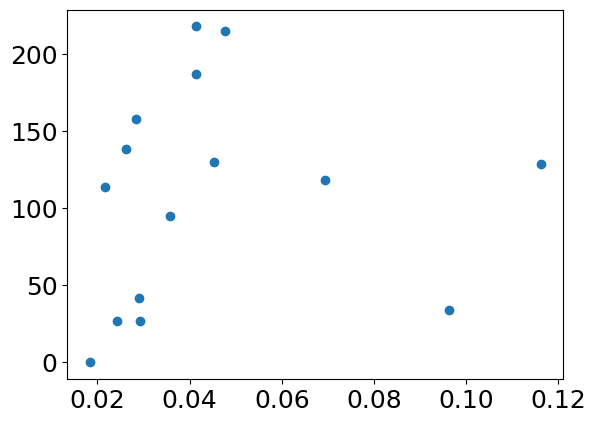

In [224]:
data = pd.read_csv(r"C:\Users\owner\Documents\Projects\dysregulated-persistence\results\data_metrics\test1.csv")
x = data['sum_denoised_ev']
y = data['fraction_non-zero']
plt.scatter(y,x)
r,p = stats.pearsonr(y,x)
print(f'P-value: {p}, R-value: {r}')